In [13]:
import pandas as pd

In [14]:
df = pd.read_parquet("out/DATA_PRP_5C/PRP1_C5_P2_V1_T2_S1/parquets/1b2b0d_fobs.parquet")

In [15]:
df_clean = df.query("value > 0.1").copy()
# df_clean = df.copy()

In [16]:
df_clean.query("var == 'I' and p == 1").sort_values(["t", "v", "i", "j", "k", "p"])

,hash_file,var,t,p,v,i,k,j,value
231,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,0,1.0,NaN,1.0,NaN,NaN,14.0
237,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,0,1.0,NaN,4.0,NaN,NaN,100.0
239,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,0,1.0,NaN,5.0,NaN,NaN,49.0
243,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,1,1.0,NaN,1.0,NaN,NaN,22.0
245,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,1,1.0,NaN,2.0,NaN,NaN,83.0
247,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,1,1.0,NaN,3.0,NaN,NaN,71.0
249,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,1,1.0,NaN,4.0,NaN,NaN,37.0
251,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,I,1,1.0,NaN,5.0,NaN,NaN,84.0


In [17]:
df_clean.query("var == 'Z'")

,hash_file,var,t,p,v,i,k,j,value
2,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,0,NaN,0.0,0.0,2.0,NaN,1.0
15,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,0,NaN,0.0,2.0,3.0,NaN,1.0
23,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,0,NaN,0.0,3.0,5.0,NaN,1.0
30,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,0,NaN,0.0,5.0,0.0,NaN,1.0
40,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,0,NaN,1.0,0.0,4.0,NaN,1.0
60,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,0,NaN,1.0,4.0,0.0,NaN,1.0
77,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,1,NaN,0.0,0.0,5.0,NaN,1.0
90,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,1,NaN,0.0,3.0,0.0,NaN,1.0
99,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,1,NaN,0.0,4.0,3.0,NaN,1.0
106,1b2b0dbdaafbade0ca832a2e79e30fa308d4bf1b,Z,1,NaN,0.0,5.0,4.0,NaN,1.0


In [18]:
df_clean['var'].unique()

array(['Z', 'X', 'Y', 'I', 'R', 'Q', 'P'], dtype=object)

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

def build_graphs_by_time(df_clean):
    """
    Constrói um grafo para cada intervalo de tempo t.
    
    Args:
        df_clean: DataFrame com variáveis Z, R, Q, I indexadas por t, v, p, i, k
        
    Returns:
        dict: Dicionário com grafos por tempo {t: G}
    """
    graphs = {}
    
    # Agrupar por tempo
    for t, df_t in df_clean.groupby('t'):
        G = nx.DiGraph()
        
        # Adicionar arestas baseado em Z (veículo usou a aresta)
        df_z = df_t[df_t['var'] == 'Z']
        
        for _, row in df_z.iterrows():
            i = row['i']  # nó origem
            k = row['k']  # nó destino
            v = row['v']  # veículo
            
            if row['value'] > 0.5:  # Z é binária
                # Buscar TODOS os valores de R para esta aresta (i, k, v)
                # R tem índices (t, v, i, k, p), então temos múltiplas linhas - uma por produto
                df_r = df_t[(df_t['var'] == 'R') & 
                           (df_t['i'] == i) & 
                           (df_t['k'] == k) & 
                           (df_t['v'] == v)].reset_index(drop=True)
                
                # Adicionar aresta se ainda não existe
                if not G.has_edge(i, k):
                    G.add_edge(i, k, vehicles=[], colors=[], weights_r=[], products=[])
                
                # Para cada produto nesta aresta, adicionar à lista
                if df_r.empty:
                    # Se não houver R para esta aresta, ainda assim adicionamos a aresta com peso 0
                    G[i][k]['vehicles'].append(v)
                    G[i][k]['colors'].append('blue' if v == 0 else 'red')
                    G[i][k]['weights_r'].append(0)
                    G[i][k]['products'].append(None)
                for x, r_row in df_r.iterrows():
                    p = r_row['p']  # produto (vem de R)
                    weight_r = r_row['value']  # valor de R
                    
                    # Definir cor baseado no veículo
                    color = 'blue' if v == 0 else 'red'
                    
                    # if x == 0:
                    G[i][k]['vehicles'].append(v)
                    G[i][k]['colors'].append(color)
                    G[i][k]['weights_r'].append(weight_r)
                    G[i][k]['products'].append(p)
        
        # Adicionar pesos dos nós (Q e I)
        nodes_data = {}
        for node in G.nodes():
            nodes_data[node] = {'Q': {}, 'I': {}}
        
        # Q: quanto o nó recebeu por produto (e, se existir, por veículo)
        df_q = df_t[df_t['var'] == 'Q']
        for _, row in df_q.iterrows():
            i = row['i']
            p = row['p']
            v = row['v'] if 'v' in row.index else None
            if i not in nodes_data:
                nodes_data[i] = {'Q': {}, 'I': {}}
            if p not in nodes_data[i]['Q']:
                nodes_data[i]['Q'][p] = {}
            # Pode haver modelos/exports sem índice v; nesse caso usamos None
            nodes_data[i]['Q'][p][v] = row['value']
        
        # I: estoque no nó de cada produto
        df_i = df_t[df_t['var'] == 'I']
        for _, row in df_i.iterrows():
            i = row['i']
            p = row['p']
            if i not in nodes_data:
                nodes_data[i] = {'Q': {}, 'I': {}}
            nodes_data[i]['I'][p] = row['value']
        
        # Garantir que o nó 0 exista (depósito)
        if 0 not in nodes_data:
            nodes_data[0] = {'Q': {}, 'I': {}}
        
        # Adicionar nodes com atributos
        for node, attrs in nodes_data.items():
            if node not in G:
                G.add_node(node)
            G.nodes[node]['Q'] = attrs['Q']
            G.nodes[node]['I'] = attrs['I']
            
            node_is_zero = False
            try:
                node_is_zero = int(node) == 0
            except (TypeError, ValueError):
                node_is_zero = (node == 0)
            G.nodes[node]['color'] = 'gray' if node_is_zero else 'lightblue'
        
        graphs[t] = G
    
    return graphs

# Construir os grafos
graphs = build_graphs_by_time(df_clean)
print(f"Total de grafos criados: {len(graphs)}")
print(f"Tempos disponíveis: {sorted(graphs.keys())}")

Total de grafos criados: 3
Tempos disponíveis: [0, 1, 2]


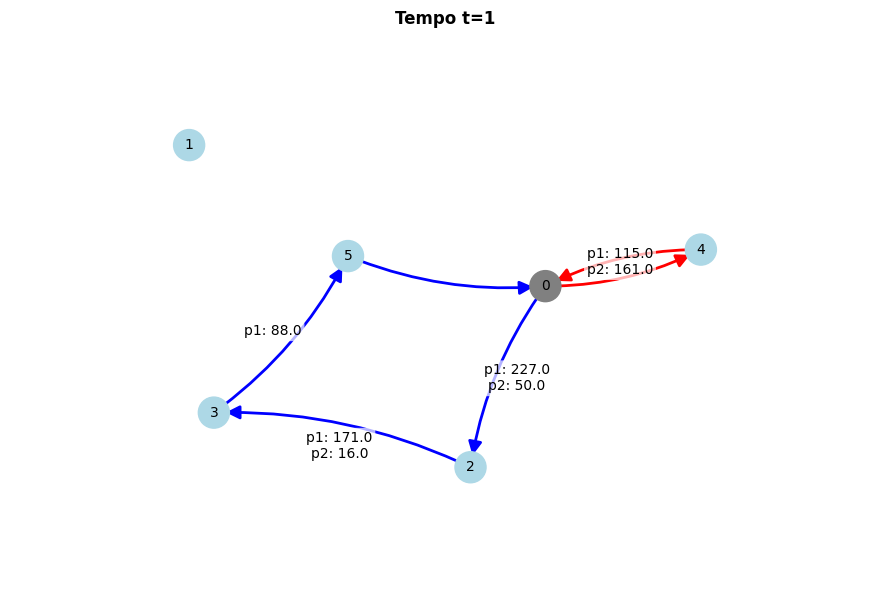

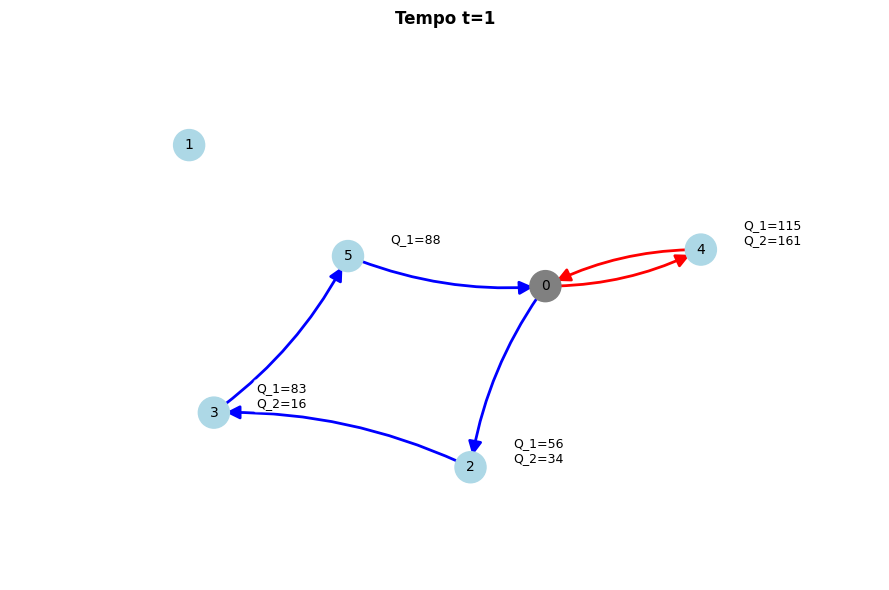

In [20]:
def visualize_graph_edges(G, t, figsize=(9, 6)):
    """
    Visualiza um grafo com arestas coloridas por veículo + labels nas arestas.
    
    Args:
        G: Grafo networkx
        t: Tempo (para título)
        figsize: Tamanho da figura
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Layout do grafo
    pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42, scale=2.5)
    
    # Desenhar nodes com tamanho fixo
    node_colors = [G.nodes[n].get('color', 'lightblue') for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=500, 
                          node_color=node_colors, ax=ax)
    
    # Desenhar arestas com cores por veículo e labels com pesos R por produto
    edge_labels = {}
    for color_name, color_hex in [('blue', '#0000FF'), ('red', '#FF0000')]:
        edges_to_draw = []
        for (i, k) in G.edges():
            if color_name in G[i][k]['colors']:
                edges_to_draw.append((i, k))
        
        # Desenhar arestas uma a uma para ajustar a curvatura quando a aresta é curta
        for (i, k) in edges_to_draw:
            x1, y1 = pos.get(i, (0, 0))
            x2, y2 = pos.get(k, (0, 0))
            length = float(((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5)
            rad = 0.25 if length < 0.6 else 0.12
            nx.draw_networkx_edges(G, pos, edgelist=[(i, k)], 
                                  edge_color=color_hex, width=2, 
                                  ax=ax, arrows=True, 
                                  arrowsize=20, connectionstyle=f'arc3,rad={rad}')
    
    # Criar labels agrupando por aresta e produto
    for (i, k) in G.edges():
        edge_data = G[i][k]
        product_r = {}  # Dicionário para acumular R por produto
        
        # Agrupar R por produto
        for j, v in enumerate(edge_data['vehicles']):
            r_val = edge_data['weights_r'][j]
            p = edge_data['products'][j]
            
            if pd.notna(p):
                p_int = int(p) + 1
                if p_int not in product_r:
                    product_r[p_int] = 0
                product_r[p_int] += r_val
        
        # Criar label com produtos e seus valores de R
        if product_r:
            label_parts = [f"p{p}: {r:.1f}" for p, r in sorted(product_r.items())]
            edge_labels[(i, k)] = "\n".join(label_parts)
    
    # Desenhar labels das arestas (com offset para não cobrir arestas curtas)
    if edge_labels:
        for (i, k), text in edge_labels.items():
            if i not in pos or k not in pos:
                continue
            x1, y1 = pos[i]
            x2, y2 = pos[k]
            mx, my = (x1 + x2) / 2.0, (y1 + y2) / 2.0
            dx, dy = (x2 - x1), (y2 - y1)
            length = float((dx * dx + dy * dy) ** 0.5) or 1e-9
            px, py = (-dy / length), (dx / length)
            sign = 1.0 if i <= k else -1.0
            n_lines = str(text).count('\\n') + 1
            base_off = 0.08 + 0.03 * max(0, n_lines - 1)
            if length < 0.6:
                base_off += 0.06
            ax.text(mx + sign * px * base_off, my + sign * py * base_off, text,
                    fontsize=10, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))
    
    # Labels dos nodes sem offset
    labels = {node: int(node) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, ax=ax)
    
    # Range do layout
    xs = [p[0] for p in pos.values()] if pos else [0]
    ys = [p[1] for p in pos.values()] if pos else [0]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # Padding para evitar nós cortados nas bordas
    x_pad = max(0.3, 0.35 * x_range)
    y_pad = max(0.3, 0.35 * y_range)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_title(f"Tempo t={int(t)+1}", fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    return fig

def visualize_graph_nodes_info(G, t, figsize=(9, 6)):
    """
    Visualiza um grafo com arestas coloridas por veículo (sem labels) + anotações I/Q nos nós.
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Layout do grafo
    pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42, scale=2.5)
    
    # Desenhar nodes
    node_colors = [G.nodes[n].get('color', 'lightblue') for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color=node_colors, ax=ax)
    
    # Desenhar arestas por veículo (sem label)
    for color_name, color_hex in [('blue', '#0000FF'), ('red', '#FF0000')]:
        edges = [(i, k) for (i, k) in G.edges() if color_name in G[i][k]['colors']]
        for (i, k) in edges:
            x1, y1 = pos.get(i, (0, 0))
            x2, y2 = pos.get(k, (0, 0))
            length = float(((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5)
            rad = 0.25 if length < 0.6 else 0.12
            nx.draw_networkx_edges(G, pos, edgelist=[(i, k)], edge_color=color_hex, width=2,
                                  ax=ax, arrows=True, arrowsize=20,
                                  connectionstyle=f'arc3,rad={rad}')
    
    # Labels dos nós
    labels = {node: int(node) for node in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, ax=ax)
    
    # Range do layout (usado para offsets/padding)
    xs = [p[0] for p in pos.values()] if pos else [0]
    ys = [p[1] for p in pos.values()] if pos else [0]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    x_off = 0.10 + 0.06 * (x_range if x_range > 0 else 1.0)
    y_off = 0.05 + 0.04 * (y_range if y_range > 0 else 1.0)
    
    def _fmt_val(val):
        try:
            f = float(val)
        except (TypeError, ValueError):
            return str(val)
        if abs(f - round(f)) < 1e-9:
            return str(int(round(f)))
        return f"{f:.1f}"
    
    node_texts = []
    for node in G.nodes():
        if node not in pos:
            continue
        inv = G.nodes[node].get('I', {}) or {}
        qdata = G.nodes[node].get('Q', {}) or {}
        
        inv_parts = []
        # for p, val in sorted(inv.items(), key=lambda x: x[0]):
        #     try:
        #         fval = float(val)
        #     except (TypeError, ValueError):
        #         continue
        #     if abs(fval) < 1e-9:
        #         continue
        #     try:
        #         p_lbl = int(p) + 1
        #     except (TypeError, ValueError):
        #         p_lbl = p
        #     inv_parts.append(f"I_{p_lbl}={_fmt_val(val)}")
        
        q_parts = []
        for p, by_v in sorted(qdata.items(), key=lambda x: x[0]):
            if by_v is None:
                continue
            try:
                p_lbl = int(p) + 1
            except (TypeError, ValueError):
                p_lbl = p
            total = 0.0
            if isinstance(by_v, dict):
                for _, val in by_v.items():
                    try:
                        total += float(val)
                    except (TypeError, ValueError):
                        continue
            else:
                try:
                    total = float(by_v)
                except (TypeError, ValueError):
                    total = 0.0
            if abs(total) < 1e-9:
                continue
            q_parts.append(f"Q_{p_lbl}={_fmt_val(total)}")
        
        lines = []
        if inv_parts:
            lines.append(", ".join(inv_parts))
        if q_parts:
            lines.append("\n".join(q_parts))
        if not lines:
            continue
        text = "\n".join(lines)
        x, y = pos[node]
        t_obj = ax.text(x + x_off, y + y_off, text, fontsize=9, ha='left', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))
        node_texts.append(t_obj)
    
    # Padding para evitar nós/anotações cortados
    x_pad = max(0.3, 0.35 * x_range)
    y_pad = max(0.3, 0.35 * y_range)
    ax.set_xlim(x_min - x_pad, x_max + x_pad)
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    
    # Evitar sobreposição entre anotações dos nós
    def _nudge_text(text_obj, dx_pix=0.0, dy_pix=0.0):
        x0, y0 = text_obj.get_position()
        x_disp, y_disp = ax.transData.transform((x0, y0))
        x_new, y_new = ax.transData.inverted().transform((x_disp + dx_pix, y_disp + dy_pix))
        text_obj.set_position((x_new, y_new))
    
    if node_texts:
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        for _ in range(40):
            moved = False
            bboxes = [t.get_window_extent(renderer=renderer) for t in node_texts]
            for i in range(len(node_texts)):
                for j in range(i + 1, len(node_texts)):
                    if bboxes[i].overlaps(bboxes[j]):
                        _nudge_text(node_texts[j], dy_pix=-10)
                        moved = True
            if not moved:
                break
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
    
    ax.set_title(f"Tempo t={int(t)+1}", fontsize=12, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    return fig

# Visualizar o primeiro grafo como exemplo
if graphs:
    first_t = sorted(graphs.keys())[0]
    fig1 = visualize_graph_edges(graphs[first_t], first_t)
    plt.show()
    fig2 = visualize_graph_nodes_info(graphs[first_t], first_t)
    plt.show()

In [21]:
def inspect_graph(G, t):
    """
    Imprime informações detalhadas de um grafo.
    """
    print(f"\n{'='*60}")
    print(f"Grafo - Tempo t={int(t)+1}")
    print(f"{'='*60}")
    print(f"Nodes: {sorted(G.nodes())}")
    print(f"Arestas: {len(G.edges())}\n")
    
    print("NODES E SEUS PESOS:")
    for node in sorted(G.nodes()):
        print(f"\n  Node {node}:")
        q_data = G.nodes[node]['Q']
        i_data = G.nodes[node]['I']
        
        if q_data:
            print(f"    Q (Recebimento): {q_data}")
        else:
            print(f"    Q (Recebimento): vazio")
            
        if i_data:
            print(f"    I (Estoque): {i_data}")
        else:
            print(f"    I (Estoque): vazio")
    
    print("\n" + "="*60)
    print("ARESTAS E SEUS PESOS:")
    for (i, k) in sorted(G.edges()):
        edge_data = G[i][k]
        print(f"\n  Aresta ({i} → {k}):")
        
        # Agrupar por produto
        product_info = {}
        for j, v in enumerate(edge_data['vehicles']):
            r_val = edge_data['weights_r'][j]
            p = edge_data['products'][j]
            color = edge_data['colors'][j]
            
            if pd.notna(p):
                p_int = int(p) + 1
                v_int = int(v) + 1
                if p_int not in product_info:
                    product_info[p_int] = []
                product_info[p_int].append((v_int, color, r_val))
        
        # Imprimir agrupado por produto
        for p_int in sorted(product_info.keys()):
            total_r = sum(r_val for _, _, r_val in product_info[p_int])
            print(f"    Produto {p_int}: R={total_r:.2f}")
            for v_int, color, r_val in product_info[p_int]:
                print(f"      - Veículo {v_int} ({color}): {r_val:.2f}")

# Inspecionar todos os grafos
for t in sorted(graphs.keys()):
    inspect_graph(graphs[t], t)


Grafo - Tempo t=1
Nodes: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]
Arestas: 6

NODES E SEUS PESOS:

  Node 0.0:
    Q (Recebimento): vazio
    I (Estoque): vazio

  Node 1.0:
    Q (Recebimento): vazio
    I (Estoque): {0.0: 11.0, 1.0: 14.0}

  Node 2.0:
    Q (Recebimento): {0.0: {0.0: 56.0}, 1.0: {0.0: 34.0}}
    I (Estoque): {0.0: 29.0}

  Node 3.0:
    Q (Recebimento): {0.0: {0.0: 83.0}, 1.0: {0.0: 16.0}}
    I (Estoque): vazio

  Node 4.0:
    Q (Recebimento): {0.0: {1.0: 115.0}, 1.0: {1.0: 161.0}}
    I (Estoque): {0.0: 89.0, 1.0: 100.0}

  Node 5.0:
    Q (Recebimento): {0.0: {0.0: 88.0}}
    I (Estoque): {0.0: 22.0, 1.0: 49.0}

ARESTAS E SEUS PESOS:

  Aresta (0.0 → 2.0):
    Produto 1: R=227.00
      - Veículo 1 (blue): 227.00
    Produto 2: R=50.00
      - Veículo 1 (blue): 50.00

  Aresta (0.0 → 4.0):
    Produto 1: R=115.00
      - Veículo 2 (red): 115.00
    Produto 2: R=161.00
      - Veículo 2 (red): 161.00

  Aresta (2.0 → 3.0):
    Produto 1: R=171.00
      - Veículo 1 (blue): 1

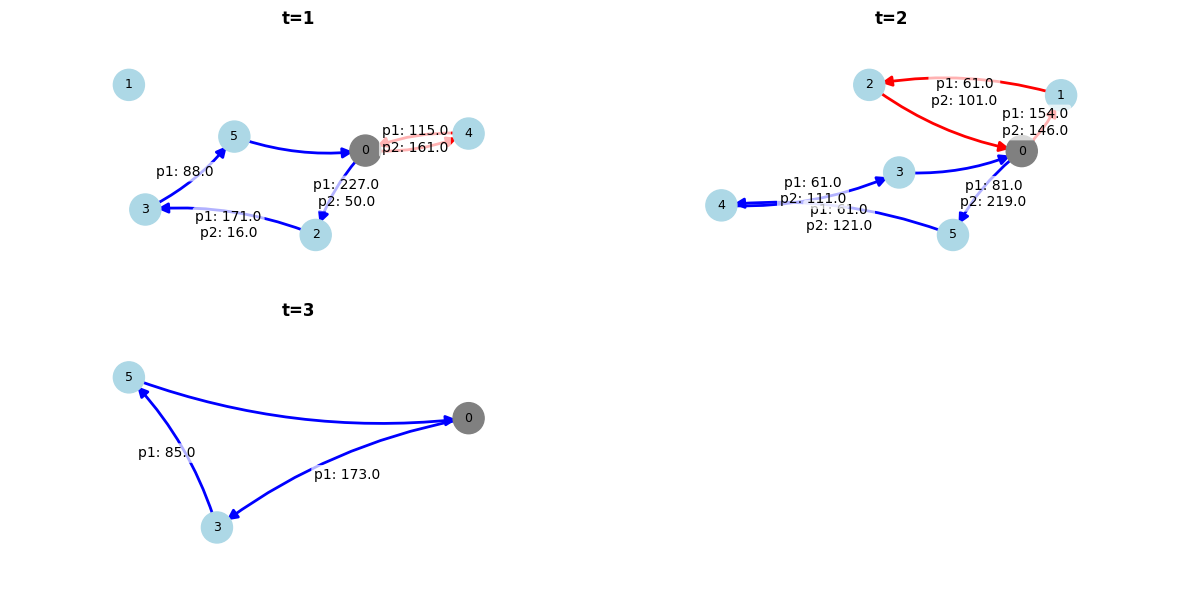

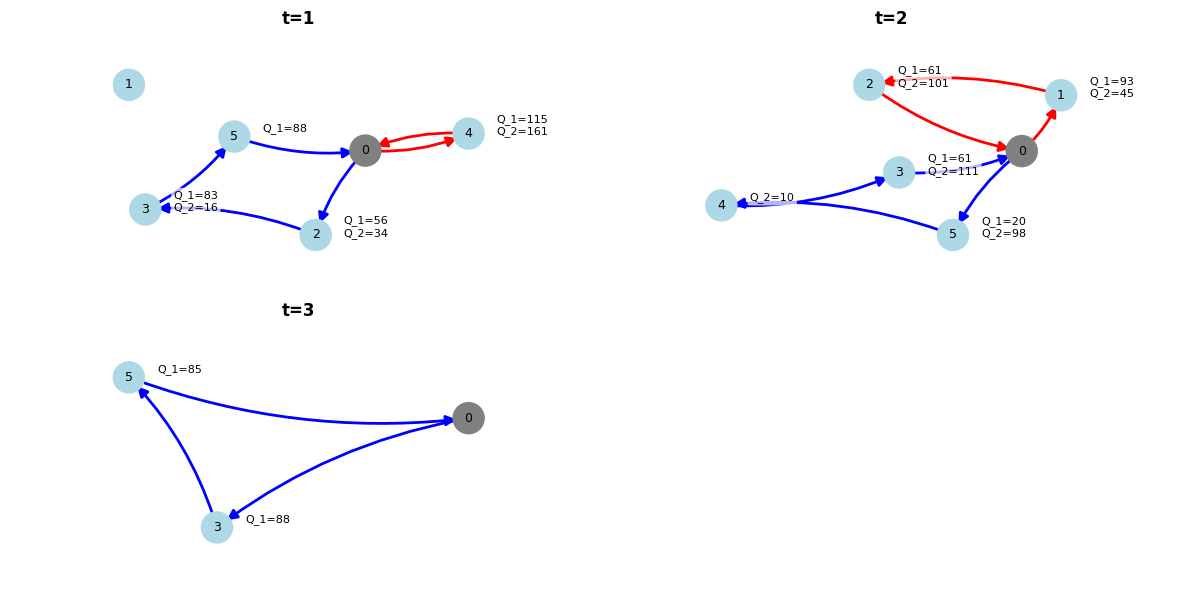

In [22]:
# Funções auxiliares para visualizar múltiplos grafos
def visualize_all_graphs_edges(graphs, max_cols=2):
    """
    Visualiza todos os grafos em um grid.
    """
    times = sorted(graphs.keys())
    n_graphs = len(times)
    n_cols = min(max_cols, n_graphs)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, t in enumerate(times):
        ax = axes[idx]
        G = graphs[t]
        
        # Layout
        pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42, scale=2.5)
        
        # Nodes com tamanho fixo
        node_colors = [G.nodes[n].get('color', 'lightblue') for n in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_size=500, 
                              node_color=node_colors, ax=ax)
        
        # Edges por veículo (cores)
        for color_name, color_hex in [('blue', '#0000FF'), ('red', '#FF0000')]:
            edges = [(i, k) for (i, k) in G.edges() 
                    if color_name in G[i][k]['colors']]
            # Desenhar arestas uma a uma para ajustar a curvatura quando a aresta é curta
            for (i, k) in edges:
                x1, y1 = pos.get(i, (0, 0))
                x2, y2 = pos.get(k, (0, 0))
                length = float(((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5)
                rad = 0.25 if length < 0.6 else 0.12
                nx.draw_networkx_edges(G, pos, edgelist=[(i, k)], 
                                      edge_color=color_hex, width=2, ax=ax,
                                      arrows=True, arrowsize=15, 
                                      connectionstyle=f'arc3,rad={rad}')
        
        # Criar labels agrupando por aresta e produto
        edge_labels = {}
        for (i, k) in G.edges():
            edge_data = G[i][k]
            product_r = {}  # Dicionário para acumular R por produto
            
            # Agrupar R por produto
            for j, v in enumerate(edge_data['vehicles']):
                r_val = edge_data['weights_r'][j]
                p = edge_data['products'][j]
                
                if pd.notna(p):
                    p_int = int(p) + 1
                    if p_int not in product_r:
                        product_r[p_int] = 0
                    product_r[p_int] += r_val
            
            # Criar label com produtos e seus valores de R
            if product_r:
                label_parts = [f"p{p}: {r:.1f}" for p, r in sorted(product_r.items())]
                edge_labels[(i, k)] = "\n".join(label_parts)
        
        # Desenhar labels das arestas (com offset para não cobrir arestas curtas)
        if edge_labels:
            for (i, k), text in edge_labels.items():
                if i not in pos or k not in pos:
                    continue
                x1, y1 = pos[i]
                x2, y2 = pos[k]
                mx, my = (x1 + x2) / 2.0, (y1 + y2) / 2.0
                dx, dy = (x2 - x1), (y2 - y1)
                length = float((dx * dx + dy * dy) ** 0.5) or 1e-9
                px, py = (-dy / length), (dx / length)
                sign = 1.0 if i <= k else -1.0
                n_lines = str(text).count('\\n') + 1
                base_off = 0.08 + 0.03 * max(0, n_lines - 1)
                if length < 0.6:
                    base_off += 0.06
                ax.text(mx + sign * px * base_off, my + sign * py * base_off, text,
                        fontsize=10, ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))
        
        # Labels dos nodes
        labels = {node: int(node) for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)
        
        # Range do layout
        xs = [p[0] for p in pos.values()] if pos else [0]
        ys = [p[1] for p in pos.values()] if pos else [0]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        x_range = x_max - x_min
        y_range = y_max - y_min
        
        # Padding para evitar nós cortados nas bordas
        x_pad = max(0.3, 0.35 * x_range)
        y_pad = max(0.3, 0.35 * y_range)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        ax.set_title(f"t={int(t)+1}", fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Remover axes não utilizados
    for idx in range(len(times), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    return fig

def visualize_all_graphs_nodes_info(graphs, max_cols=2):
    """Visualiza todos os grafos em um grid (arestas sem label + anotações I/Q nos nós)."""
    times = sorted(graphs.keys())
    n_graphs = len(times)
    n_cols = min(max_cols, n_graphs)
    n_rows = (n_graphs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3*n_rows))
    if n_graphs == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, t in enumerate(times):
        ax = axes[idx]
        G = graphs[t]
        
        pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42, scale=2.5)
        
        node_colors = [G.nodes[n].get('color', 'lightblue') for n in G.nodes()]
        nx.draw_networkx_nodes(G, pos, node_size=500, node_color=node_colors, ax=ax)
        
        for color_name, color_hex in [('blue', '#0000FF'), ('red', '#FF0000')]:
            edges = [(i, k) for (i, k) in G.edges() if color_name in G[i][k]['colors']]
            for (i, k) in edges:
                x1, y1 = pos.get(i, (0, 0))
                x2, y2 = pos.get(k, (0, 0))
                length = float(((x2 - x1) ** 2 + (y2 - y1) ** 2) ** 0.5)
                rad = 0.25 if length < 0.6 else 0.12
                nx.draw_networkx_edges(G, pos, edgelist=[(i, k)], edge_color=color_hex, width=2,
                                      ax=ax, arrows=True, arrowsize=15,
                                      connectionstyle=f'arc3,rad={rad}')
        
        labels = {node: int(node) for node in G.nodes()}
        nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)
        
        xs = [p[0] for p in pos.values()] if pos else [0]
        ys = [p[1] for p in pos.values()] if pos else [0]
        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)
        x_range = x_max - x_min
        y_range = y_max - y_min
        
        x_off = 0.10 + 0.06 * (x_range if x_range > 0 else 1.0)
        y_off = 0.05 + 0.04 * (y_range if y_range > 0 else 1.0)
        
        def _fmt_val(val):
            try:
                f = float(val)
            except (TypeError, ValueError):
                return str(val)
            if abs(f - round(f)) < 1e-9:
                return str(int(round(f)))
            return f"{f:.1f}"
        
        node_texts = []
        for node in G.nodes():
            if node not in pos:
                continue
            inv = G.nodes[node].get('I', {}) or {}
            qdata = G.nodes[node].get('Q', {}) or {}
            
            inv_parts = []
            # for p, val in sorted(inv.items(), key=lambda x: x[0]):
            #     try:
            #         fval = float(val)
            #     except (TypeError, ValueError):
            #         continue
            #     if abs(fval) < 1e-9:
            #         continue
            #     try:
            #         p_lbl = int(p) + 1
            #     except (TypeError, ValueError):
            #         p_lbl = p
            #     inv_parts.append(f"I_{p_lbl}={_fmt_val(val)}")
            
            q_parts = []
            for p, by_v in sorted(qdata.items(), key=lambda x: x[0]):
                if by_v is None:
                    continue
                try:
                    p_lbl = int(p) + 1
                except (TypeError, ValueError):
                    p_lbl = p
                total = 0.0
                if isinstance(by_v, dict):
                    for _, val in by_v.items():
                        try:
                            total += float(val)
                        except (TypeError, ValueError):
                            continue
                else:
                    try:
                        total = float(by_v)
                    except (TypeError, ValueError):
                        total = 0.0
                if abs(total) < 1e-9:
                    continue
                q_parts.append(f"Q_{p_lbl}={_fmt_val(total)}")
            
            lines = []
            if inv_parts:
                lines.append(", ".join(inv_parts))
            if q_parts:
                lines.append("\n".join(q_parts))
            if not lines:
                continue
            text = "\n".join(lines)
            x, y = pos[node]
            t_obj = ax.text(x + x_off, y + y_off, text, fontsize=8, ha='left', va='center',
                            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.7))
            node_texts.append(t_obj)
        
        x_pad = max(0.3, 0.35 * x_range)
        y_pad = max(0.3, 0.35 * y_range)
        ax.set_xlim(x_min - x_pad, x_max + x_pad)
        ax.set_ylim(y_min - y_pad, y_max + y_pad)
        
        def _nudge_text(text_obj, dx_pix=0.0, dy_pix=0.0):
            x0, y0 = text_obj.get_position()
            x_disp, y_disp = ax.transData.transform((x0, y0))
            x_new, y_new = ax.transData.inverted().transform((x_disp + dx_pix, y_disp + dy_pix))
            text_obj.set_position((x_new, y_new))
        
        if node_texts:
            fig.canvas.draw()
            renderer = fig.canvas.get_renderer()
            for _ in range(40):
                moved = False
                bboxes = [t.get_window_extent(renderer=renderer) for t in node_texts]
                for i in range(len(node_texts)):
                    for j in range(i + 1, len(node_texts)):
                        if bboxes[i].overlaps(bboxes[j]):
                            _nudge_text(node_texts[j], dy_pix=-10)
                            moved = True
                if not moved:
                    break
                fig.canvas.draw()
                renderer = fig.canvas.get_renderer()
        
        ax.set_title(f"t={int(t)+1}", fontsize=12, fontweight='bold')
        ax.axis('off')
    
    for idx in range(len(times), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    return fig

# Visualizar todos os grafos
if len(graphs) > 0:
    fig1 = visualize_all_graphs_edges(graphs)
    plt.show()
    fig2 = visualize_all_graphs_nodes_info(graphs)
    plt.show()

In [23]:
def get_graph_dataframe(G, t):
    """
    Converte um grafo em DataFrames para análise mais fácil.
    
    Returns:
        (df_edges, df_nodes): DataFrames com dados do grafo
    """
    # DataFrame de arestas - agregando por produto
    edges_data = []
    for (i, k) in G.edges():
        edge_data = G[i][k]
        product_r = {}  # Acumular R por produto
        
        for j, v in enumerate(edge_data['vehicles']):
            r_val = edge_data['weights_r'][j]
            p = edge_data['products'][j]
            
            if pd.notna(p):
                p_int = int(p) + 1
                if p_int not in product_r:
                    product_r[p_int] = 0
                product_r[p_int] += r_val
        
        # Criar uma linha por produto
        for p_int, total_r in product_r.items():
            edges_data.append({
                't': t,
                'origem': i,
                'destino': k,
                'produto': p_int,
                'peso_r': total_r
            })
    
    df_edges = pd.DataFrame(edges_data) if edges_data else pd.DataFrame()
    
    # DataFrame de nodes
    nodes_data = []
    for node in G.nodes():
        q_dict = G.nodes[node]['Q']
        i_dict = G.nodes[node]['I']
        
        # Criar uma linha por produto
        all_products = set(q_dict.keys()) | set(i_dict.keys())
        for p in all_products:
            nodes_data.append({
                't': t,
                'no': node,
                'produto': p,
                'Q': q_dict.get(p, 0),
                'I': i_dict.get(p, 0)
            })
    
    df_nodes = pd.DataFrame(nodes_data) if nodes_data else pd.DataFrame()
    
    return df_edges, df_nodes

# Exemplo: Converter cada grafo para DataFrames
graph_edges_list = []
graph_nodes_list = []

for t in sorted(graphs.keys()):
    df_e, df_n = get_graph_dataframe(graphs[t], t)
    graph_edges_list.append(df_e)
    graph_nodes_list.append(df_n)

# Combinar todos em um único DataFrame
df_all_edges = pd.concat(graph_edges_list, ignore_index=True) if graph_edges_list else pd.DataFrame()
df_all_nodes = pd.concat(graph_nodes_list, ignore_index=True) if graph_nodes_list else pd.DataFrame()

print("\nDataFrame de ARESTAS (amostra):")
print(df_all_edges.head(10))

print("\nDataFrame de NODES (amostra):")
print(df_all_nodes.head(10))


DataFrame de ARESTAS (amostra):
   t  origem  destino  produto  peso_r
0  0     0.0      2.0        1   227.0
1  0     0.0      2.0        2    50.0
2  0     0.0      4.0        1   115.0
3  0     0.0      4.0        2   161.0
4  0     2.0      3.0        1   171.0
5  0     2.0      3.0        2    16.0
6  0     3.0      5.0        1    88.0
7  1     0.0      5.0        1    81.0
8  1     0.0      5.0        2   219.0
9  1     0.0      1.0        1   154.0

DataFrame de NODES (amostra):
   t   no  produto             Q      I
0  0  2.0      0.0   {0.0: 56.0}   29.0
1  0  2.0      1.0   {0.0: 34.0}    0.0
2  0  3.0      0.0   {0.0: 83.0}    0.0
3  0  3.0      1.0   {0.0: 16.0}    0.0
4  0  5.0      0.0   {0.0: 88.0}   22.0
5  0  5.0      1.0             0   49.0
6  0  4.0      0.0  {1.0: 115.0}   89.0
7  0  4.0      1.0  {1.0: 161.0}  100.0
8  0  1.0      0.0             0   11.0
9  0  1.0      1.0             0   14.0
